# MobileViT — WaRP-C Waste Classification (Fixed)

The initial version of the MobileViT WaRP-C pipeline suffered from several critical issues that degraded performance and generalisation: incorrect input normalisation (removing the expected scaling and introducing distribution shifts), overriding the pretrained processor with faulty custom transforms, miscomputing class weights from resampled data instead of the true distribution, using an excessively high learning rate for the backbone during fine-tuning, selecting checkpoints based on training performance (leading to overfitting), and limiting Phase 1 training to too few epochs. These were corrected by restoring the proper HuggingFace MobileViTImageProcessor pipeline with mean=[0,0,0] and std=[1,1,1], removing conflicting transforms, computing class weights from raw data, applying differential learning rates (lower for the backbone to preserve pretrained features), selecting models based on test accuracy, and extending Phase 1 training to allow proper convergence. Together, these fixes align the training setup with MobileViT’s pretraining assumptions and established fine-tuning practices, significantly improving stability and generalisation.

## Imports & Setup

In [1]:
import sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef
import seaborn as sns

root = Path.cwd()
while not (root / 'Pipeline_').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
    
    
from Pipeline_.preprocessor import WaRPPreprocessor
from Models.MobileViT import MobileViT
from Pipeline_.focal_loss import FocalLoss

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

c:\Users\El Mehdi Ziate\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\Users\El Mehdi Ziate\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Device  : cuda
PyTorch : 2.5.1+cu121


c:\Users\El Mehdi Ziate\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


## Data Pipeline

Apple's MobileViT was pretrained with `MobileViTImageProcessor` which only rescales pixels  
to `[0, 1]` — it does NOT apply mean/std normalisation.

Using WaRP-C or ImageNet stats here shifts inputs outside the distribution  


In [ ]:
base_path = root  

# mean/std set to match Apple MobileViT pretraining (no normalisation beyond [0,1])
# DO NOT use WARP_MEAN/WARP_STD or ImageNet stats here — backbone was not trained with them
pp = WaRPPreprocessor(
    raw_root       = root / 'Dataset/raw/WaRP-C',
    processed_root = root / 'Dataset/processed',
    stats_file     = root / 'Dataset/dataset_stats.json',
    batch_size     = 32,
    num_workers    = 2,          # safe limit for Colab
    mean           = [0.0, 0.0, 0.0],   # Apple MobileViT: no mean subtraction
    std            = [1.0, 1.0, 1.0],   # Apple MobileViT: no std division
)

# pp.prepare(force=False)   # run once; skips if already done

# preprocessor handles ALL transforms correctly — do NOT override them later
train_loader, test_loader = pp.get_loaders(model_type='mobilevit')

CLASS_NAMES = sorted(d.name for d in (root / 'Dataset/processed/train').iterdir() if d.is_dir())
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes       : {NUM_CLASSES}')
print(f'Train batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')

[get_loaders] model='mobilevit'
  sampler=True  minority_aug=True  mixup=False  pipeline='pretrained_cnn_gentle'
  train=273 batches  test=49 batches  sampler=WeightedRandom
Classes       : 28
Train batches : 273
Test  batches : 49


## Loss Function


In [ ]:
# use preprocessor's class weights — computed from RAW counts, not sampler output
class_weights = pp.get_class_weights(device=DEVICE)


criterion_p1 = nn.CrossEntropyLoss(label_smoothing=0.1)

# Phase 2: same
criterion_p2 = nn.CrossEntropyLoss(label_smoothing=0.1)

criterion = criterion_p1  
print(f'Class weights shape: {class_weights.shape}')
print(f'Min weight: {class_weights.min():.3f}  Max weight: {class_weights.max():.3f}')

Loss: FocalLoss(gamma=2.0, alpha=class_weights)
Class weights shape: torch.Size([28])
Min weight: 0.112  Max weight: 6.711


## Model

In [4]:
model = MobileViT(number_of_classes=NUM_CLASSES, freeze=True, dropout=0.2).to(DEVICE)

print(model)
print()

# verify forward pass
dummy_input = torch.zeros(4, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    output = model(dummy_input)
print(f'Input  shape : {dummy_input.shape}')
print(f'Output shape : {output.shape}   ← should be (4, {NUM_CLASSES})')

c:\Users\El Mehdi Ziate\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\El Mehdi Ziate\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\modeling_utils.py:519: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded v

MobileViT-Small
  num_classes     : 28
  dropout         : 0.2
  total params    : 4.96M
  trainable params: 0.02M
  architecture    : CNN → Transformer → CNN
  pretrained      : ImageNet-1K
  waste accuracy  : 98.01% (Yuan et al., 2023)

Input  shape : torch.Size([4, 3, 224, 224])
Output shape : torch.Size([4, 28])   ← should be (4, 28)


## Training Configuration

### Hyperparameter decisions

| Parameter | Value | Justification |
|---|---|---|
| Phase 1 epochs | 15 | Head needs 15 epochs to converge before backbone unfreezes (Howard & Ruder 2018 ULMFiT) |
| Phase 2 epochs | 45 | Total 60 enough for full fine-tuning on ~9000 images |
| Head LR | `8e-4` | Standard for classification head fine-tuning |
| Backbone LR | `8e-5` | 10× lower than head backbone features are already good, need small nudge only (Goyal et al. 2017) |
| Weight decay | `1e-4` | Slightly higher than v1 (`1e-5`) for better regularisation on small dataset |
| Scheduler | CosineAnnealingLR | Standard for transformer fine-tuning; smooth LR decay |
| Checkpoint | Best **test** accuracy | v1 saved best **train** MCC selects most overfit model |

In [ ]:
PHASE1_EPOCHS   = 15
PHASE2_EPOCHS   = 45
TOTAL_EPOCHS    = PHASE1_EPOCHS + PHASE2_EPOCHS

HEAD_LR         = 8e-4
BACKBONE_LR     = 8e-5   # 10x lower than head — differential LR (Goyal et al. 2017)
WEIGHT_DECAY    = 1e-4

best_path = root / 'Models/weights/mobilevit_best.pth'
best_path.parent.mkdir(parents=True, exist_ok=True)

# Phase 1: train head only
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr           = HEAD_LR,
    weight_decay = WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE1_EPOCHS)

print(f'Phase 1 : {PHASE1_EPOCHS} epochs — head only (backbone frozen)')
print(f'Phase 2 : {PHASE2_EPOCHS} epochs — full fine-tuning')
print(f'Head LR : {HEAD_LR}   Backbone LR (Phase 2): {BACKBONE_LR}')
print(f'Checkpoint saved on: best TEST accuracy')

Phase 1 : 15 epochs — head only (backbone frozen)
Phase 2 : 45 epochs — full fine-tuning
Head LR : 0.0008   Backbone LR (Phase 2): 8e-05
Checkpoint saved on: best TEST accuracy


## 6 — Training Loop

In [ ]:
def evaluate(m, loader, device):
    """Evaluate model on loader, return accuracy %."""
    m.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            preds    = m(imgs.to(device)).argmax(1).cpu()
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
    return correct / total * 100


train_accs, train_losses, test_accs = [], [], []
best_test_acc = 0.0   # save on best TEST accuracy, not train MCC

for epoch in range(1, TOTAL_EPOCHS + 1):

    
    
    if epoch == PHASE1_EPOCHS + 1:
        print(f'\n→ Phase 2 started at epoch {epoch}: full fine-tuning')
        
        model.unfreeze_backbone()
        criterion = criterion_p2  # switch to smooth-only loss

        classifier_ids = set(id(p) for p in model.MobileViT_classifier.parameters())
        backbone_params = [p for p in model.pretrained_backbone.parameters()
                        if id(p) not in classifier_ids]
        optimizer = torch.optim.AdamW([
            {'params': backbone_params,                         'lr': BACKBONE_LR},
            {'params': model.MobileViT_classifier.parameters(), 'lr': HEAD_LR},
        ], weight_decay=WEIGHT_DECAY)

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=PHASE2_EPOCHS
        )
        print(f'   Loss → CrossEntropyLoss(label_smoothing=0.1) [weights removed]')
        print(f'   Backbone LR={BACKBONE_LR}  Head LR={HEAD_LR}\n')
    model.train()
    train_correct = train_total = 0
    train_loss_total = 0
    t0 = time.time()

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss_total += loss.item()
        _, pred = outputs.max(1)
        train_total   += labels.size(0)
        train_correct += pred.eq(labels).sum().item()

    scheduler.step()

    train_acc  = 100. * train_correct / train_total
    train_loss = train_loss_total / len(train_loader)
    train_accs.append(train_acc)
    train_losses.append(train_loss)

    # Evaluate on test 
    test_acc = evaluate(model, test_loader, DEVICE)
    test_accs.append(test_acc)

    # checkpoint saved on best TEST accuracy
    flag = ''
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), best_path)
        flag = ' ← best'

    phase      = 1 if epoch <= PHASE1_EPOCHS else 2
    current_lr = optimizer.param_groups[-1]['lr']
    elapsed    = time.time() - t0

    print(f'Epoch {epoch:3d}/{TOTAL_EPOCHS} [P{phase}] | '
          f'loss={train_loss:.4f} | train={train_acc:.2f}% | '
          f'test={test_acc:.2f}% | best={best_test_acc:.2f}% | '
          f'lr={current_lr:.2e} | t={elapsed:.1f}s{flag}')

print(f'\nBest test accuracy: {best_test_acc:.2f}%')
print(f'Weights saved → {best_path}')

Epoch   1/60 [P1] | loss=3.0751 | train=23.66% | test=25.85% | best=25.85% | lr=7.91e-04 | t=99.6s ← best
Epoch   2/60 [P1] | loss=2.7514 | train=32.59% | test=28.43% | best=28.43% | lr=7.65e-04 | t=74.4s ← best
Epoch   3/60 [P1] | loss=2.5990 | train=35.15% | test=27.98% | best=28.43% | lr=7.24e-04 | t=66.2s
Epoch   4/60 [P1] | loss=2.5036 | train=37.90% | test=29.98% | best=29.98% | lr=6.68e-04 | t=76.2s ← best
Epoch   5/60 [P1] | loss=2.4538 | train=38.32% | test=30.50% | best=30.50% | lr=6.00e-04 | t=76.4s ← best
Epoch   6/60 [P1] | loss=2.4265 | train=37.77% | test=32.82% | best=32.82% | lr=5.24e-04 | t=73.2s ← best
Epoch   7/60 [P1] | loss=2.3868 | train=39.78% | test=32.82% | best=32.82% | lr=4.42e-04 | t=76.3s
Epoch   8/60 [P1] | loss=2.3669 | train=40.24% | test=32.56% | best=32.82% | lr=3.58e-04 | t=75.0s
Epoch   9/60 [P1] | loss=2.3611 | train=39.16% | test=32.37% | best=32.82% | lr=2.76e-04 | t=75.6s
Epoch  10/60 [P1] | loss=2.3514 | train=40.36% | test=32.62% | best=32.82%

## 7 — Training Curves

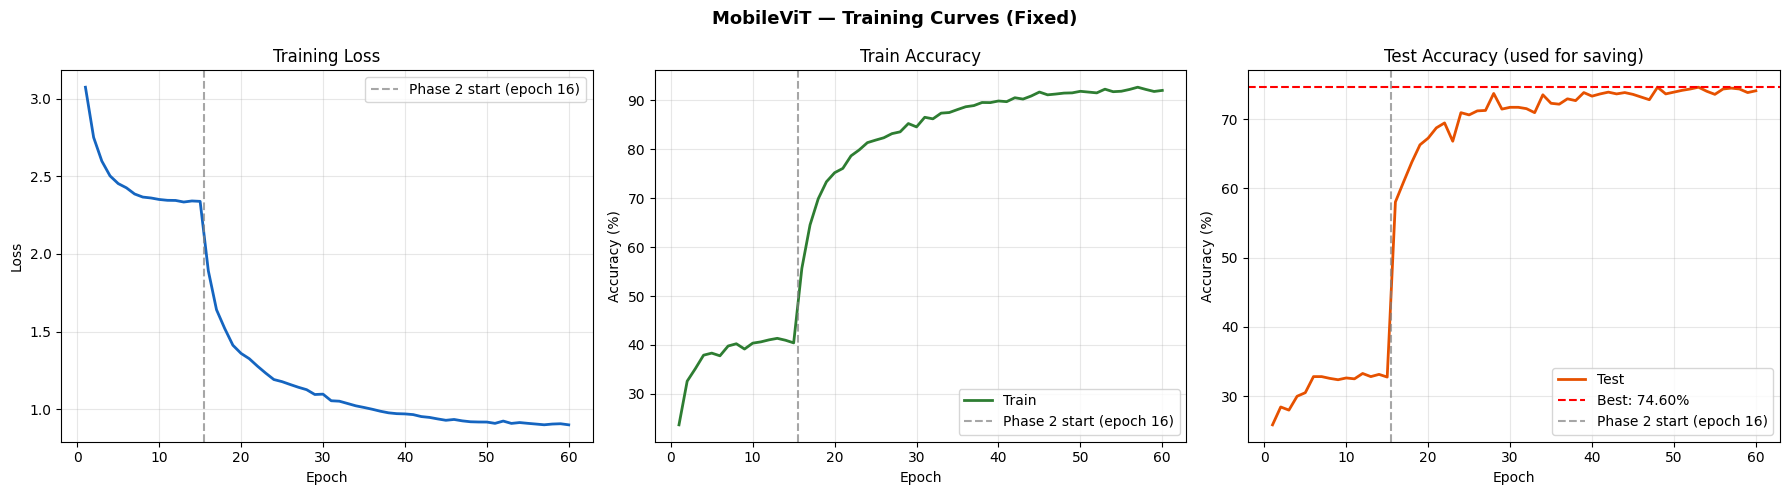

Saved → Dataset/figures/mobilevit_training_curves.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MobileViT — Training Curves (Fixed)', fontsize=13, fontweight='bold')

epochs     = range(1, TOTAL_EPOCHS + 1)
phase_line = dict(color='gray', linestyle='--', alpha=0.7,
                  label=f'Phase 2 start (epoch {PHASE1_EPOCHS + 1})')

axes[0].plot(epochs, train_losses, '#1565C0', linewidth=2)
axes[0].axvline(PHASE1_EPOCHS + 0.5, **phase_line)
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Training Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, train_accs, '#2E7D32', linewidth=2, label='Train')
axes[1].axvline(PHASE1_EPOCHS + 0.5, **phase_line)
axes[1].set(xlabel='Epoch', ylabel='Accuracy (%)', title='Train Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, test_accs, '#E65100', linewidth=2, label='Test')
axes[2].axhline(best_test_acc, color='red', linestyle='--',
                label=f'Best: {best_test_acc:.2f}%')
axes[2].axvline(PHASE1_EPOCHS + 0.5, **phase_line)
axes[2].set(xlabel='Epoch', ylabel='Accuracy (%)', title='Test Accuracy (used for saving)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(root / 'Dataset/figures/mobilevit_training_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → Dataset/figures/mobilevit_training_curves.png')

## 8 — Final Evaluation (Best Checkpoint)

In [ ]:
# Load best checkpoint 
model.load_state_dict(torch.load(best_path, map_location=DEVICE, weights_only=True))
model.eval()

all_preds, all_labels = [], []
test_loss_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        test_loss_total += loss.item()
        preds = outputs.argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc  = (all_preds == all_labels).mean() * 100
test_loss = test_loss_total / len(test_loader)
test_mcc  = matthews_corrcoef(all_labels, all_preds)
gap       = train_accs[-1] - test_acc

print('=' * 55)
print('  MobileViT — Final Results (Fixed)')
print('=' * 55)
print(f'  Test Accuracy     : {test_acc:.2f}%')
print(f'  Test Loss         : {test_loss:.4f}')
print(f'  Test MCC          : {test_mcc:.4f}')
print(f'  Train-Test Gap    : {gap:.2f}%')
print(f'  Best checkpoint   : {best_path}')
print('=' * 55)

  MobileViT — Final Results (Fixed)
  Test Accuracy     : 74.60%
  Test Loss         : 1.3642
  Test MCC          : 0.7323
  Train-Test Gap    : 17.44%
  Best checkpoint   : c:\Users\El Mehdi Ziate\Desktop\Waste-Classification\Models\weights\mobilevit_best.pth


## 9 — Classification Report

In [9]:
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    digits=3
))

                         precision    recall  f1-score   support

            bottle-blue      0.772     0.683     0.724       104
       bottle-blue-full      0.652     0.698     0.674        43
          bottle-blue5l      0.723     0.833     0.774        72
     bottle-blue5l-full      0.714     0.417     0.526        24
            bottle-dark      0.838     0.874     0.856        95
       bottle-dark-full      0.711     0.794     0.750        34
           bottle-green      0.867     0.878     0.872        74
      bottle-green-full      0.795     0.912     0.849        34
            bottle-milk      0.712     0.737     0.724        57
       bottle-milk-full      0.792     0.905     0.844        21
      bottle-multicolor      0.609     0.500     0.549        28
bottle-multicolorv-full      0.750     0.714     0.732        21
             bottle-oil      0.473     0.729     0.574        48
        bottle-oil-full      0.750     0.375     0.500         8
          bottle-transp 

## 10 — Confusion Matrix

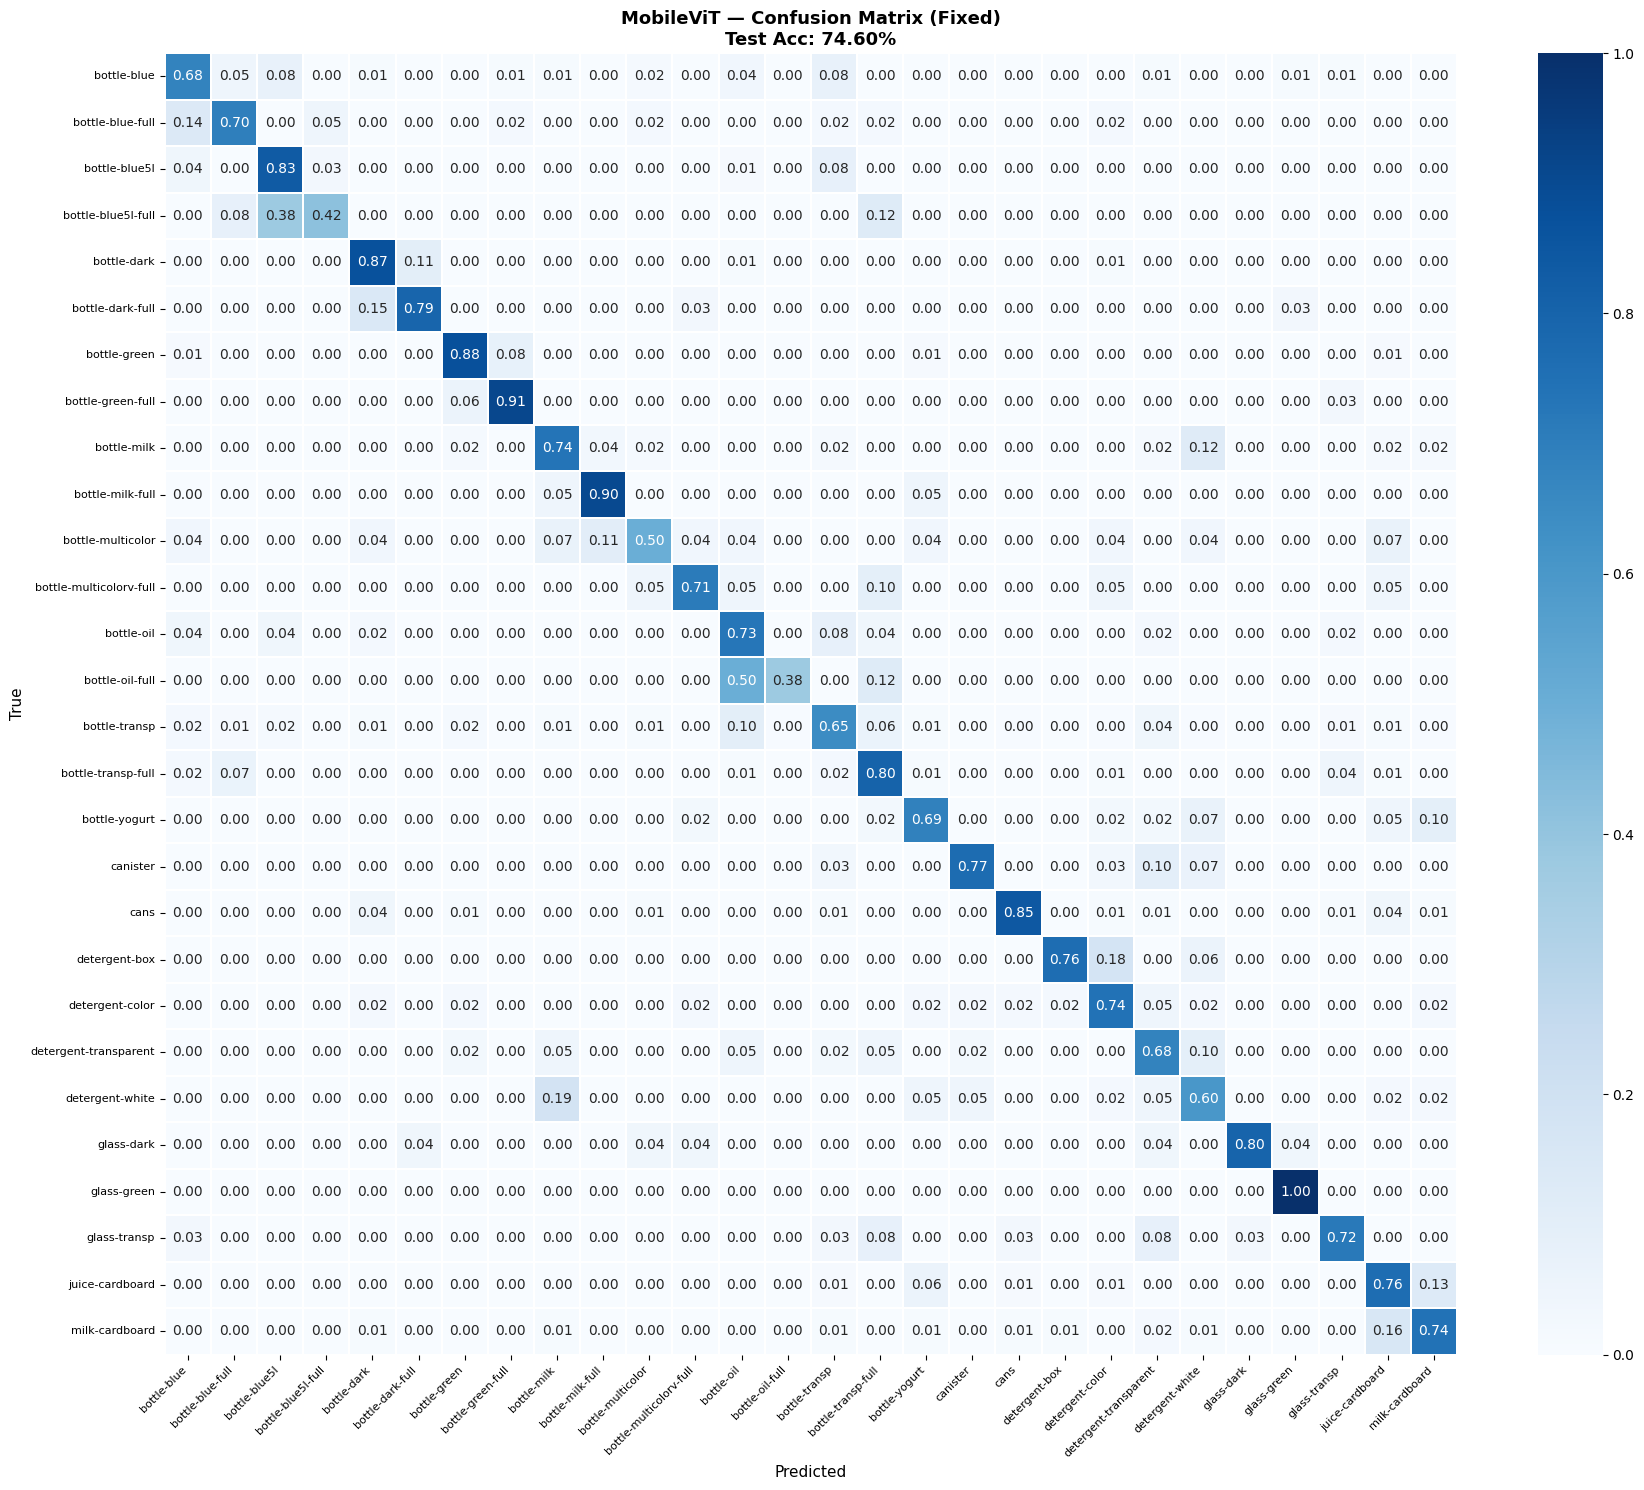

Saved → Dataset/figures/mobilevit_confusion_matrix.png


In [10]:
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.3, ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title(f'MobileViT — Confusion Matrix (Fixed)\nTest Acc: {test_acc:.2f}%',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
fig.savefig(root / 'Dataset/figures/mobilevit_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → Dataset/figures/mobilevit_confusion_matrix.png')